In [1]:
pip install CBFV

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from CBFV import composition

C:\Users\Vallamsetti Devika\anaconda3\Lib\site-packages\CBFV\composition.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
import pkg_resources

In [4]:
df = pd.read_csv('cleaned_cp_dataset.csv')

In [5]:
df.head(10)

,formula,T,Cp
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625
5,B2O3,900.0,116.190
6,B2O3,800.0,111.169
7,B2O3,723.0,106.692
8,B2O3,700.0,105.228
9,B2O3,600.0,98.115


In [6]:
df = df.rename(columns={'Formula': 'formula', 'Cp': 'target'})

In [7]:
df.head(10)

,formula,T,target
0,B2O3,1400.0,134.306
1,B2O3,1300.0,131.294
2,B2O3,1200.0,128.072
3,B2O3,1100.0,124.516
4,B2O3,1000.0,120.625
5,B2O3,900.0,116.190
6,B2O3,800.0,111.169
7,B2O3,723.0,106.692
8,B2O3,700.0,105.228
9,B2O3,600.0,98.115


✅ Successfully exported 2 publication-ready figures at 300 DPI.


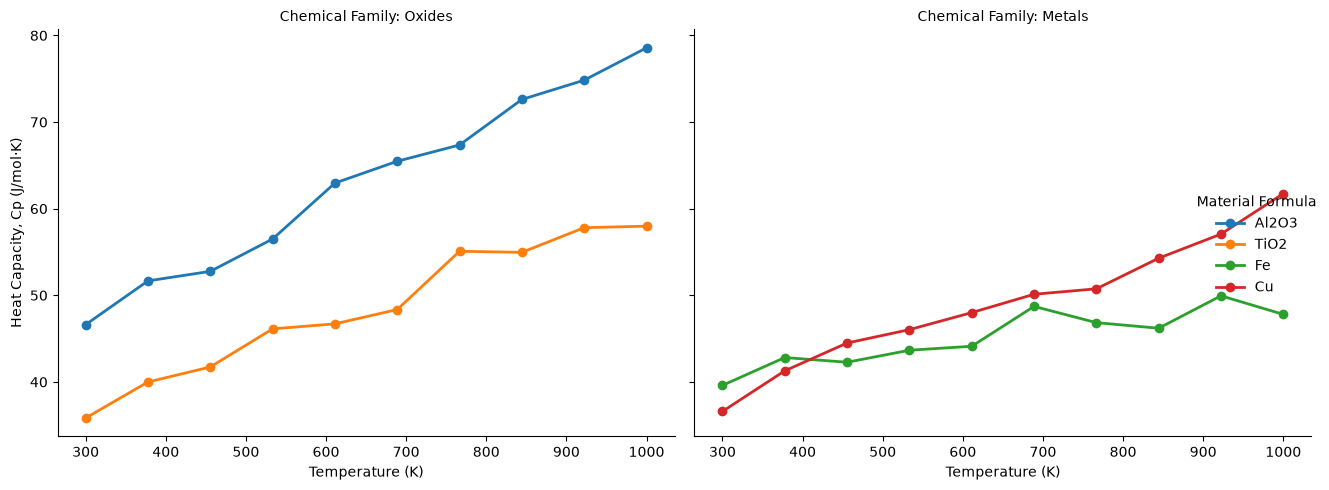

In [10]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate sample dataset
np.random.seed(42)
data = []
families = {"Oxides": ["Al2O3", "TiO2"], "Metals": ["Fe", "Cu"]}
T_range = np.linspace(300, 1000, 10)

for family, formulas in families.items():
    for formula in formulas:
        a, b = np.random.uniform(20, 50), np.random.uniform(0.01, 0.05)
        for T in T_range:
            Cp = a + b * T + np.random.normal(0, 1.5)
            data.append({"family": family, "formula": formula, "T": T, "Cp": Cp})

df = pd.DataFrame(data)

# 2. Clean column header whitespace (prevents KeyError)
df.columns = df.columns.str.strip()

# 3. Create FacetGrid across chemical families
g = sns.FacetGrid(df, col="family", hue="formula", height=5, aspect=1.2, palette="tab10")
g.map(plt.plot, "T", "Cp", marker="o", linewidth=2)
g.add_legend(title="Material Formula")

# 4. Format labels and titles
g.set_axis_labels("Temperature (K)", "Heat Capacity, Cp (J/mol·K)")
g.set_titles(col_template="Chemical Family: {col_name}")

# 5. Optimize layout and export high-resolution figures
plt.tight_layout()
plt.savefig("Cp_vs_T_FacetGrid.png", dpi=300, bbox_inches="tight")
plt.savefig("Cp_vs_T_FacetGrid.pdf", dpi=300, bbox_inches="tight")

# 6. Display output and release memory
print("✅ Successfully exported 2 publication-ready figures at 300 DPI.")
plt.show()
plt.close("all")